In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")

import pandas as pd
from src.cleaning import load_processed
from src.metrics import add_core_metrics

df = add_core_metrics(load_processed())
print(df[["total_system_load", "net_daily_intake"]].isna().sum())   # 355 and 355
rep = df[df["is_reported"]]      # reported days only (720 rows)

total_system_load    355
net_daily_intake     355
dtype: int64


In [2]:
print(rep["total_system_load"].describe().round(0))
print("peak:", rep["total_system_load"].idxmax().date())
print("low :", rep["total_system_load"].idxmin().date())

count      720.0
mean      6233.0
std       2918.0
min       2002.0
25%       2501.0
50%       6634.0
75%       8250.0
max      11762.0
Name: total_system_load, dtype: Float64
peak: 2023-12-20
low : 2025-08-24


In [3]:
yr = rep.groupby(rep.index.year).agg(
    avg_load=("total_system_load", "mean"),
    peak_load=("total_system_load", "max"),
    low_load=("total_system_load", "min"),
    avg_net=("net_daily_intake", "mean"),
)
yr.round(1)

,avg_load,peak_load,low_load,avg_net
date,,,,
2023,8846.5,11762,5730,-131.0
2024,7319.9,10994,5947,3.4
2025,2575.7,6471,2002,-12.4


In [4]:
n = rep["net_daily_intake"]
print("positive:", (n > 0).sum(), " negative:", (n < 0).sum(), " zero:", (n == 0).sum())
rep.groupby(rep.index.year)["net_daily_intake"].apply(lambda s: (s > 0).mean()).round(3)

positive: 238  negative: 475  zero: 7


date
2023    0.052
2024    0.590
2025    0.326
Name: net_daily_intake, dtype: float64

<Axes: title={'center': 'Total System Load (reported days)'}, xlabel='date'>

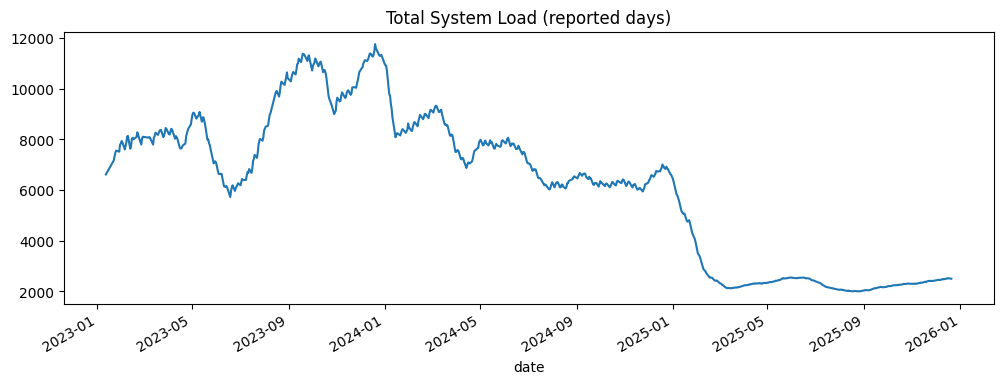

In [5]:
rep["total_system_load"].astype(float).plot(
    figsize=(12, 4), title="Total System Load (reported days)")

In [6]:
check = rep.groupby(rep.index.year).agg(
    first_hhs=("hhs_care", "first"),
    last_hhs=("hhs_care", "last"),
    sum_net_intake=("net_daily_intake", "sum"),
)
check["actual_change"] = check["last_hhs"] - check["first_hhs"]
check

,first_hhs,last_hhs,sum_net_intake,actual_change
date,,,,
2023,6566,11230,-30120,4664
2024,10870,6454,863,-4416
2025,6405,2484,-2955,-3921
